# 05. Modelo SparkML multiclase

Entrena Logistic Regression, **SparkXGBClassifier** y One-vs-Rest LinearSVC sobre la matriz muestra × genes (200 genes seleccionados en 04). Usa el mismo split por paciente (`refined_split_pacientes`) y ponderacion por clase en los tres modelos. El XGBoost es el modelo final.

In [ ]:
%run ./00_configuracion.py

PROJECT_DIR: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga
RAW_DIR: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\raw
RAW_METADATA_FILE: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\raw\metadata\metadatos_tcga_oficial_18_clases.csv
RAW_RNASEQ_PATH: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\raw\rnaseq
LOCAL_DATA_DIR: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local
Spark: 4.1.2


In [2]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression,
    LinearSVC,
    OneVsRest
)
from xgboost.spark import SparkXGBClassifier
from xgboost.collective import Config as XGBCollectiveConfig
from pyspark.ml.functions import vector_to_array

import time
import itertools
import gc
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

# ============================================================
# Parámetros locales del experimento SparkML
# ============================================================

MODO_PRUEBA_LOCAL = True

# Número máximo de genes usados por SparkML.
# En local conviene dejarlo bajo para que no se demore demasiado.
MAX_GENES_SPARKML = 200

print("MODO_PRUEBA_LOCAL:", MODO_PRUEBA_LOCAL)
print("MAX_GENES_SPARKML:", MAX_GENES_SPARKML)


MODO_PRUEBA_LOCAL: True
MAX_GENES_SPARKML: 200


In [3]:
df_long = read_trusted(TRUSTED_LONG_PATH)
df_samples = read_trusted(TRUSTED_SAMPLES_PATH)
df_fs = load_spark_table("refined_rfe_feature_importances")
print("Genes cargados desde refined_rfe_feature_importances")

def detectar_columna_gen(df):
    for c in ["gene_id_base", "gene", "feature", "variable", "gen"]:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró columna de gen. Columnas: {df.columns}")

col_gen = detectar_columna_gen(df_fs)

if "importance" in df_fs.columns:
    df_genes_ordenados = (
        df_fs.select(F.col(col_gen).alias("gene_id_base"), F.col("importance").cast("double").alias("importance"))
        .dropna(subset=["gene_id_base"])
        .dropDuplicates(["gene_id_base"])
        .orderBy(F.desc("importance"))
    )
else:
    df_genes_ordenados = (
        df_fs.select(F.col(col_gen).alias("gene_id_base"))
        .dropna(subset=["gene_id_base"])
        .dropDuplicates(["gene_id_base"])
        .withColumn("importance", F.lit(None).cast("double"))
    )

genes_modelo = [r["gene_id_base"] for r in df_genes_ordenados.select("gene_id_base").collect()][:MAX_GENES_SPARKML]
print("Genes usados:", len(genes_modelo), genes_modelo[:10])

pdf_genes_modelo = pd.DataFrame({
    "orden": range(1, len(genes_modelo)+1),
    "gene_id_base": genes_modelo,
    "metodo_seleccion": "RFE_XGBoost_multiclase_local",
    "tabla_origen": "refined_rfe_feature_importances",
    "n_genes_total": len(genes_modelo)
})
save_spark_table(spark.createDataFrame(pdf_genes_modelo), "refined_rfe_genes_seleccionados_multiclase")

Genes cargados desde refined_rfe_feature_importances
Genes usados: 200 ['ENSG00000167751', 'ENSG00000128242', 'ENSG00000131095', 'ENSG00000109072', 'ENSG00000106927', 'ENSG00000042832', 'ENSG00000177807', 'ENSG00000077498', 'ENSG00000143167', 'ENSG00000198758']
Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_rfe_genes_seleccionados_multiclase


WindowsPath('C:/Users/mirol/Documents/AAcien/Integrador/notebooks_locales_tcga/notebooks_locales_tcga/data_local/refined/tables/refined_rfe_genes_seleccionados_multiclase')

In [4]:
df_long_modelo = (
    df_long
    .filter(F.col("gene_id_base").isin(genes_modelo))
    .select("sample_id", "patient_id", "cancer_type", "gene_id_base", "log2_tpm")
)

df_matriz = (
    df_long_modelo
    .groupBy("sample_id", "patient_id", "cancer_type")
    .pivot("gene_id_base", genes_modelo)
    .agg(F.first("log2_tpm"))
    .fillna(0.0)
)

columnas_base = ["sample_id", "patient_id", "cancer_type"]
columnas_genes = [c for c in genes_modelo if c in df_matriz.columns]

for c in columnas_genes:
    df_matriz = df_matriz.withColumn(c, F.coalesce(F.col(c).cast("double"), F.lit(0.0)))

df_matriz = df_matriz.select(*columnas_base, *columnas_genes)

print("Matriz:", df_matriz.count(), "filas x", len(df_matriz.columns), "columnas")
mostrar(df_matriz, 5)

save_spark_table(df_matriz, "refined_ml_matriz_rfe_200_genes")
save_spark_table(df_matriz, "refined_ml_matriz_modelado_desde_feature_selection")

Matriz: 8335 filas x 203 columnas


,sample_id,patient_id,cancer_type,ENSG00000167751,ENSG00000128242,ENSG00000131095,ENSG00000109072,ENSG00000106927,ENSG00000042832,ENSG00000177807,...,ENSG00000144339,ENSG00000165905,ENSG00000129354,ENSG00000117595,ENSG00000136160,ENSG00000086548,ENSG00000160182,ENSG00000169474,ENSG00000132437,ENSG00000158874
0,8bc46a09-7328-42e0-ad97-e557ec81048e,TCGA-A3-3365,KIRC,0.015926,6.161912,0.178619,1.127435,1.417974,0.368824,1.894178,...,0.100574,3.913665,3.605826,3.721876,8.491441,0.033934,0.363451,0.000000,4.970509,1.228111
1,2c9bfc03-d4e6-47be-a046-1e2efd086bf0,TCGA-B0-5080,KIRC,0.000000,6.219445,0.441271,0.794187,0.690641,0.616922,0.188654,...,0.000000,1.011853,1.493084,1.487538,5.722392,0.306146,0.000000,2.982218,1.857901,0.000000
2,68b5218b-b7f0-4549-af44-dfcbf327bc48,TCGA-B8-A54H,KIRC,0.000000,8.413495,0.615699,0.735609,1.364797,0.884637,0.285343,...,0.036890,5.156793,4.895201,4.022705,7.020936,0.738379,0.497536,0.000000,8.140321,0.000000
3,18714b14-6138-46af-99a1-24acbc326530,TCGA-B0-5092,KIRC,0.025596,7.742118,0.844305,0.309176,0.594357,0.561008,1.252839,...,0.013927,1.945870,3.677441,0.783247,5.302246,0.132511,1.183899,0.000000,4.869082,0.311271
4,3f733c5c-acbf-4e59-b8d9-c8f754970db3,TCGA-B2-5633,KIRC,0.030407,4.733278,0.657183,2.114933,0.944783,0.778461,0.720454,...,1.973464,1.611645,2.038822,3.574695,6.389155,1.299303,0.349705,0.000000,2.944109,1.279947


Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_ml_matriz_rfe_200_genes
Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_ml_matriz_modelado_desde_feature_selection


WindowsPath('C:/Users/mirol/Documents/AAcien/Integrador/notebooks_locales_tcga/notebooks_locales_tcga/data_local/refined/tables/refined_ml_matriz_modelado_desde_feature_selection')

In [5]:
# Split de pacientes desde refined_split_pacientes
df_split = load_spark_table("refined_split_pacientes").select("patient_id", "split")

df_matriz_split = df_matriz.join(df_split, on="patient_id", how="inner")
df_train = df_matriz_split.filter(F.col("split") == "train").drop("split")
df_val = df_matriz_split.filter(F.col("split") == "validation").drop("split")
df_test = df_matriz_split.filter(F.col("split") == "test").drop("split")

print("Train:", df_train.count(), "Validation:", df_val.count(), "Test:", df_test.count())
mostrar(df_train.groupBy("cancer_type").agg(F.count("*").alias("n")).orderBy(F.desc("n")), 30)

conteo_train = df_train.groupBy("cancer_type").agg(F.count("*").alias("n_clase"))
n_train = df_train.count()
n_clases = conteo_train.count()

df_pesos = (
    conteo_train
    .withColumn("class_weight", F.lit(n_train) / (F.lit(n_clases) * F.col("n_clase")))
    .select("cancer_type", "class_weight")
)

df_train = df_train.join(df_pesos, on="cancer_type", how="left").fillna({"class_weight": 1.0})
df_val = df_val.join(df_pesos, on="cancer_type", how="left").fillna({"class_weight": 1.0})
df_test = df_test.join(df_pesos, on="cancer_type", how="left").fillna({"class_weight": 1.0})

Train: 5827 Validation: 1249 Test: 1259


,cancer_type,n
0,BRCA,773
1,UCEC,384
2,KIRC,375
3,LUAD,368
4,HNSC,364
5,LGG,361
6,THCA,354
7,PRAD,351
8,LUSC,351
9,COAD,329


In [6]:
label_indexer_base = StringIndexer(inputCol="cancer_type", outputCol="label", handleInvalid="error")
assembler_base = VectorAssembler(inputCols=columnas_genes, outputCol="features_raw", handleInvalid="keep")
scaler_base = StandardScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)

label_names_global = list(label_indexer_base.fit(df_train).labels)
print("Clases:", label_names_global)

def crear_pipeline(clf):
    return Pipeline(stages=[label_indexer_base, assembler_base, scaler_base, clf])

def grid_dict(**kwargs):
    keys = list(kwargs.keys())
    values = [kwargs[k] for k in keys]
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]

def obtener_labels_pipeline(modelo):
    return list(modelo.stages[0].labels)

def predicciones_a_pandas(predicciones, labels):
    base = ["sample_id", "patient_id", "cancer_type", "label", "prediction"]
    if "probability" in predicciones.columns:
        pdf = predicciones.select(*base, vector_to_array("probability").alias("proba")).toPandas()
        probas = np.vstack(pdf["proba"].apply(lambda x: np.array(x, dtype=float)).values)
    else:
        pdf = predicciones.select(*base).toPandas()
        probas = None
    pdf["label"] = pdf["label"].astype(int)
    pdf["prediction"] = pdf["prediction"].astype(int)
    pdf["cancer_predicho"] = pdf["prediction"].apply(lambda i: labels[int(i)])
    return pdf, probas

def calcular_metricas(nombre_modelo, split, pred, labels):
    pdf, probas = predicciones_a_pandas(pred, labels)
    y_true, y_pred = pdf["label"].values, pdf["prediction"].values
    clases = list(range(len(labels)))
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, labels=clases, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, labels=clases, average="weighted", zero_division=0)
    roc = pr = np.nan
    if probas is not None and probas.shape[1] == len(clases):
        try:
            roc = roc_auc_score(y_true, probas, labels=clases, multi_class="ovr", average="macro")
        except Exception:
            pass
        try:
            pr = average_precision_score(label_binarize(y_true, classes=clases), probas, average="macro")
        except Exception:
            pass
    return {
        "modelo": nombre_modelo, "split": split,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(p_macro), "recall_macro": float(r_macro), "f1_macro": float(f1_macro),
        "precision_weighted": float(p_w), "recall_weighted": float(r_w), "f1_weighted": float(f1_w),
        "roc_auc_macro_ovr": None if np.isnan(roc) else float(roc),
        "pr_auc_macro_ovr": None if np.isnan(pr) else float(pr),
    }

Clases: ['BRCA', 'UCEC', 'KIRC', 'LUAD', 'HNSC', 'LGG', 'THCA', 'LUSC', 'PRAD', 'COAD', 'OV', 'STAD', 'BLCA', 'LIHC', 'CESC', 'KIRP', 'GBM', 'SKCM']


In [7]:
# Factories de modelos SparkML

def factory_logistic_regression(params):
    return LogisticRegression(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        weightCol="class_weight",
        family="multinomial",
        maxIter=params["maxIter"],
        regParam=params["regParam"],
        elasticNetParam=params["elasticNetParam"]
    )


def factory_xgboost(params):
    return SparkXGBClassifier(
        features_col="features",
        label_col="label",
        prediction_col="prediction",
        probability_col="probability",
        raw_prediction_col="rawPrediction",
        weight_col="class_weight",
        num_workers=1,
        coll_cfg=XGBCollectiveConfig(tracker_host_ip="127.0.0.1"),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        min_child_weight=params["min_child_weight"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"]
    )


def factory_one_vs_rest_linear_svc(params):
    base_svc = LinearSVC(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        rawPredictionCol="rawPrediction",
        weightCol="class_weight",
        maxIter=params["maxIter"],
        regParam=params["regParam"]
    )

    return OneVsRest(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        classifier=base_svc
    )


## Comparación baseline (una corrida por modelo)

Entrena cada modelo una vez con hiperparámetros por defecto razonables y compara su `f1_macro` en validación. Justifica elegir XGBoost para el ajuste fino. El test no se toca aquí.

Baseline (SparkML): LogisticRegression_multinomial
Baseline (SparkML): OneVsRest_LinearSVC
ERROR OneVsRest_LinearSVC : [FIELD_NOT_FOUND] No such struct field `class_weight` in `label`, `features`, `mc2b$0`. SQLSTATE: 42704
Baseline (in-memory): XGBoost


,modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr
3,XGBoost_inmemory,train,1.000000,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
0,LogisticRegression_multinomial,train,0.954694,0.953438,0.949326,0.953438,0.950955,0.955647,0.954694,0.954801,0.998785,0.984599
4,XGBoost_inmemory,validation,0.971978,0.971209,NaN,NaN,0.970741,NaN,NaN,NaN,NaN,NaN
1,LogisticRegression_multinomial,validation,0.953563,0.950963,0.947854,0.950963,0.948377,0.955258,0.953563,0.953480,0.998576,0.984726
2,OneVsRest_LinearSVC,validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_metricas_modelos_sparkml
Figura guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\visualizations\comparacion_baseline_f1_macro.png


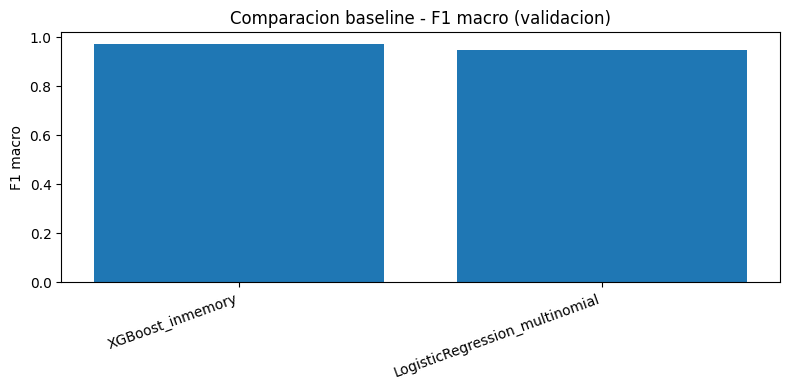

In [8]:
# Comparacion baseline: una corrida por modelo
# LogReg y SVC en SparkML; XGBoost in-memory (SparkXGBClassifier usa barrier mode y no corre en Spark local)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

filas_baseline = []

# 1) Modelos SparkML (no usan barrier)
spark_baseline = [
    ("LogisticRegression_multinomial", factory_logistic_regression,
        {"maxIter": 80, "regParam": 0.05, "elasticNetParam": 0.0}),
    ("OneVsRest_LinearSVC", factory_one_vs_rest_linear_svc,
        {"maxIter": 50, "regParam": 0.05}),
]
for nombre, factory, params in spark_baseline:
    print("Baseline (SparkML):", nombre)
    try:
        modelo = crear_pipeline(factory(params)).fit(df_train)
        labels = obtener_labels_pipeline(modelo)
        for split, sdf in [("train", df_train), ("validation", df_val)]:
            filas_baseline.append(calcular_metricas(nombre, split, modelo.transform(sdf), labels))
    except Exception as e:
        print("ERROR", nombre, ":", e)
        filas_baseline.append({"modelo": nombre, "split": "validation", "f1_macro": None})
    finally:
        try:
            spark.catalog.clearCache()
        except Exception:
            pass
        gc.collect()

# 2) XGBoost in-memory (rapido, sin barrier de Spark)
print("Baseline (in-memory): XGBoost")
from xgboost import XGBClassifier

def _baseline_xy(sdf):
    pdf = sdf.select(*columnas_genes, "cancer_type").toPandas()
    X = pdf[columnas_genes].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy("float32")
    return X, pdf["cancer_type"]

_le_base = LabelEncoder()
Xtr_b, ytr_raw = _baseline_xy(df_train)
Xva_b, yva_raw = _baseline_xy(df_val)
ytr_b = _le_base.fit_transform(ytr_raw)
yva_b = _le_base.transform(yva_raw)

xgb_base = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, objective="multi:softprob", eval_metric="mlogloss",
                         tree_method="hist", random_state=SEED, n_jobs=-1)
xgb_base.fit(Xtr_b, ytr_b, sample_weight=compute_sample_weight("balanced", ytr_b))
for split, X, y in [("train", Xtr_b, ytr_b), ("validation", Xva_b, yva_b)]:
    yp = xgb_base.predict(X)
    filas_baseline.append({"modelo": "XGBoost_inmemory", "split": split,
                           "accuracy": float(accuracy_score(y, yp)),
                           "balanced_accuracy": float(balanced_accuracy_score(y, yp)),
                           "f1_macro": float(f1_score(y, yp, average="macro"))})

pdf_baseline = pd.DataFrame(filas_baseline)
display(pdf_baseline.sort_values(["split", "f1_macro"], ascending=[True, False]))
save_spark_table(spark.createDataFrame(pdf_baseline), "refined_metricas_modelos_sparkml")

val_base = (pdf_baseline[pdf_baseline["split"] == "validation"]
            .dropna(subset=["f1_macro"]).sort_values("f1_macro", ascending=False))
plt.figure(figsize=(8, 4))
plt.bar(val_base["modelo"], val_base["f1_macro"])
plt.title("Comparacion baseline - F1 macro (validacion)")
plt.ylabel("F1 macro"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); guardar_figura("comparacion_baseline_f1_macro.png"); plt.show()

## Ajuste de hiperparámetros (XGBoost) — multi-entorno

`ajustar_hiperparametros(entorno, ...)` con la misma interfaz para tres situaciones:
`"databricks"` (SparkML `CrossValidator`, folds por paciente), `"pc_gpu"` y `"pc_cpu"` (Optuna + `StratifiedGroupKFold` por paciente + early stopping). Optimiza `f1_macro` (en Spark, `f1` ponderado del evaluador nativo).

In [9]:
# === Ajuste de hiperparametros multi-entorno ===
# entorno: "databricks" (SparkML distribuido) | "pc_gpu" (in-memory GPU) | "pc_cpu" (in-memory CPU)
import os
import numpy as np
from sklearn.metrics import f1_score


def detectar_entorno():
    if os.environ.get("DATABRICKS_RUNTIME_VERSION"):
        return "databricks"
    try:
        import subprocess
        subprocess.check_output(["nvidia-smi"], stderr=subprocess.DEVNULL)
        return "pc_gpu"
    except Exception:
        return "pc_cpu"


def _device_xgb(entorno):
    return "cuda" if entorno == "pc_gpu" else "cpu"


def tune_xgboost_inmemory(X, y, groups, entorno, n_trials=40, n_folds=5,
                          seed=42, n_estimators_max=600, early_stopping=40):
    """Optuna (TPE) + StratifiedGroupKFold por paciente + early stopping. Optimiza f1_macro."""
    import optuna
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedGroupKFold
    from sklearn.utils.class_weight import compute_sample_weight

    device = _device_xgb(entorno)
    X = np.asarray(X, dtype="float32"); y = np.asarray(y); groups = np.asarray(groups)
    splits = list(StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed).split(X, y, groups))

    def objective(trial):
        params = dict(
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            gamma=trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        )
        scores = []
        for tr_idx, va_idx in splits:
            sw = compute_sample_weight("balanced", y[tr_idx])
            model = XGBClassifier(
                n_estimators=n_estimators_max, early_stopping_rounds=early_stopping,
                objective="multi:softprob", eval_metric="mlogloss",
                device=device, tree_method="hist", random_state=seed, n_jobs=-1, **params,
            )
            model.fit(X[tr_idx], y[tr_idx], sample_weight=sw,
                      eval_set=[(X[va_idx], y[va_idx])], verbose=False)
            scores.append(f1_score(y[va_idx], model.predict(X[va_idx]), average="macro"))
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials)
    return {"best_params": study.best_params, "best_f1_macro": study.best_value, "study": study}


def _agregar_fold_col(sdf, group_col, n_folds, seed):
    from pyspark.sql import functions as F
    from pyspark.sql.window import Window
    pac = (sdf.select(group_col).distinct()
              .withColumn("_rnd", F.rand(seed))
              .withColumn("_rn", F.row_number().over(Window.orderBy("_rnd")))
              .withColumn("fold", (F.col("_rn") % F.lit(n_folds)).cast("int"))
              .select(group_col, "fold"))
    return sdf.join(pac, on=group_col, how="inner")


def tune_xgboost_spark(sdf, feature_cols, label_col, group_col, entorno,
                       n_folds=5, seed=42, grid=None, usar_gpu=False):
    """CrossValidator de SparkML con folds por paciente (foldCol). Metrica del evaluador: f1 ponderado."""
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import VectorAssembler, StringIndexer
    from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator
    from xgboost.spark import SparkXGBClassifier

    gpu = usar_gpu or (entorno == "pc_gpu")
    sdf_f = _agregar_fold_col(sdf, group_col, n_folds, seed)
    indexer = StringIndexer(inputCol=label_col, outputCol="label", handleInvalid="keep")
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="keep")
    xgb = SparkXGBClassifier(features_col="features", label_col="label",
                             device="cuda" if gpu else "cpu", tree_method="hist",
                             eval_metric="mlogloss", num_workers=1, random_state=seed)
    pipe = Pipeline(stages=[indexer, assembler, xgb])
    if grid is None:
        grid = (ParamGridBuilder()
                .addGrid(xgb.max_depth, [5, 6, 8])
                .addGrid(xgb.learning_rate, [0.05, 0.1])
                .addGrid(xgb.n_estimators, [200, 400])
                .addGrid(xgb.reg_lambda, [1.0, 3.0])
                .build())
    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
    cv = CrossValidator(estimator=pipe, estimatorParamMaps=grid, evaluator=evaluator,
                        numFolds=n_folds, foldCol="fold", parallelism=2, seed=seed)
    cv_model = cv.fit(sdf_f)
    best_idx = int(np.argmax(cv_model.avgMetrics))
    best_params = {p.name: v for p, v in cv_model.getEstimatorParamMaps()[best_idx].items()}
    return {"best_model": cv_model.bestModel, "cv_model": cv_model,
            "avg_metrics": cv_model.avgMetrics, "best_f1_weighted": float(max(cv_model.avgMetrics)),
            "best_params": best_params}


def ajustar_hiperparametros(entorno, sdf, feature_cols, label_col, group_col,
                            n_trials=40, n_folds=5, seed=42, n_estimators_max=600):
    """Dispatcher unico: mismas entradas para los tres entornos."""
    if entorno == "databricks":
        return tune_xgboost_spark(sdf, feature_cols, label_col, group_col, entorno,
                                  n_folds=n_folds, seed=seed)
    if entorno in ("pc_gpu", "pc_cpu"):
        from sklearn.preprocessing import LabelEncoder
        pdf = sdf.select(*feature_cols, label_col, group_col).toPandas()
        X = pdf[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy("float32")
        le = LabelEncoder(); y = le.fit_transform(pdf[label_col])
        groups = pdf[group_col].to_numpy()
        out = tune_xgboost_inmemory(X, y, groups, entorno, n_trials, n_folds, seed, n_estimators_max)
        out["label_encoder"] = le
        return out
    raise ValueError("entorno debe ser 'databricks', 'pc_gpu' o 'pc_cpu'")

In [10]:
ENTORNO = os.getenv("TCGA_ENTORNO", detectar_entorno())
print("Entorno de tuning:", ENTORNO)

resultado_tuning = ajustar_hiperparametros(
    entorno=ENTORNO,
    sdf=df_train.select(*columnas_genes, "cancer_type", "patient_id"),
    feature_cols=columnas_genes,
    label_col="cancer_type",
    group_col="patient_id",
    n_trials=int(os.getenv("TCGA_N_TRIALS", "40")),
    n_folds=int(os.getenv("TCGA_N_FOLDS", "5")),
    seed=SEED,
)
print(resultado_tuning.get("best_params", resultado_tuning))

Entorno de tuning: pc_gpu


[I 2026-06-05 15:49:39,105] A new study created in memory with name: no-name-34ade56f-c09d-4b52-874a-8bca261794a2
C:\Users\mirol\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:751: UserWarning: [15:49:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-06-05 15:49:58,564] Trial 0 finished with value: 0.9615575102830128 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516848, 'min_child_weight': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 1.7699302940633311e-07, 'reg_lambd

{'max_depth': 4, 'learning_rate': 0.28275192290887713, 'min_child_weight': 4, 'subsample': 0.8519416923901437, 'colsample_bytree': 0.6653364163479973, 'reg_alpha': 1.5368176468926634e-06, 'reg_lambda': 0.04020236761412425, 'gamma': 0.011514186645364053}


## Refit final y evaluación en test

Reentrena el modelo final con los `best_params` y mide **una sola vez** en test. Devuelve también las predicciones de test para el diagnóstico.

In [11]:
def refit_final(entorno, resultado_tuning, sdf_train, sdf_val, sdf_test,
                feature_cols, label_col="cancer_type", seed=42,
                n_estimators_max=600, early_stopping=40):
    """Reentrena el modelo final con los mejores hiperparametros y evalua una vez en test."""
    if entorno == "databricks":
        modelo = resultado_tuning["best_model"]
        labels = obtener_labels_pipeline(modelo)
        filas = [calcular_metricas("XGBoost_final", split, modelo.transform(sdf), labels)
                 for split, sdf in [("train", sdf_train), ("validation", sdf_val), ("test", sdf_test)]]
        pred_pdf, probas = predicciones_a_pandas(modelo.transform(sdf_test), labels)
        pred_pdf["probabilidad_maxima"] = probas.max(axis=1) if probas is not None else np.nan
        return {"modelo": modelo, "metricas": pd.DataFrame(filas),
                "pred_test_pdf": pred_pdf, "clases": list(labels)}

    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
    from sklearn.utils.class_weight import compute_sample_weight
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

    device = "cuda" if entorno == "pc_gpu" else "cpu"
    best = dict(resultado_tuning["best_params"])
    le = resultado_tuning.get("label_encoder") or LabelEncoder().fit(
        sdf_train.select(label_col).toPandas()[label_col])

    def to_pdf(sdf):
        return sdf.select("sample_id", "patient_id", label_col, *feature_cols).toPandas()

    def XY(pdf):
        X = pdf[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy("float32")
        return X, le.transform(pdf[label_col])

    pdf_tr, pdf_va, pdf_te = to_pdf(sdf_train), to_pdf(sdf_val), to_pdf(sdf_test)
    Xtr, ytr = XY(pdf_tr); Xva, yva = XY(pdf_va); Xte, yte = XY(pdf_te)

    modelo = XGBClassifier(n_estimators=n_estimators_max, early_stopping_rounds=early_stopping,
                           objective="multi:softprob", eval_metric="mlogloss",
                           device=device, tree_method="hist", random_state=seed, n_jobs=-1, **best)
    modelo.fit(Xtr, ytr, sample_weight=compute_sample_weight("balanced", ytr),
               eval_set=[(Xva, yva)], verbose=False)

    filas = []
    for split, X, y in [("train", Xtr, ytr), ("validation", Xva, yva), ("test", Xte, yte)]:
        yp = modelo.predict(X)
        filas.append({"modelo": "XGBoost_final", "split": split,
                      "accuracy": float(accuracy_score(y, yp)),
                      "balanced_accuracy": float(balanced_accuracy_score(y, yp)),
                      "f1_macro": float(f1_score(y, yp, average="macro"))})

    y_pred_te = modelo.predict(Xte)
    proba_te = modelo.predict_proba(Xte)
    pred_pdf = pd.DataFrame({
        "sample_id": pdf_te["sample_id"].values,
        "patient_id": pdf_te["patient_id"].values,
        "cancer_type": pdf_te[label_col].values,
        "label": yte, "prediction": y_pred_te,
        "cancer_predicho": le.inverse_transform(y_pred_te),
        "probabilidad_maxima": proba_te.max(axis=1),
    })
    print("Reporte en test:")
    print(classification_report(yte, y_pred_te, target_names=list(le.classes_), zero_division=0))
    return {"modelo": modelo, "label_encoder": le, "metricas": pd.DataFrame(filas),
            "pred_test_pdf": pred_pdf, "clases": list(le.classes_),
            "best_iteration": getattr(modelo, "best_iteration", None)}

In [12]:
import joblib

final = refit_final(
    entorno=ENTORNO,
    resultado_tuning=resultado_tuning,
    sdf_train=df_train, sdf_val=df_val, sdf_test=df_test,
    feature_cols=columnas_genes, label_col="cancer_type", seed=SEED,
)
display(final["metricas"])
save_spark_table(spark.createDataFrame(final["metricas"]), "refined_metricas_modelo_final")

pdf_hiper = pd.DataFrame([{"modelo": "XGBoost_final", "parametro": k, "valor": str(v)}
                          for k, v in (resultado_tuning.get("best_params") or {}).items()])
if not pdf_hiper.empty:
    save_spark_table(spark.createDataFrame(pdf_hiper), "refined_hiperparametros_modelos_sparkml")

if ENTORNO == "databricks":
    final["modelo"].write().overwrite().save(path_str(MODELS_PATH / "modelo_final_sparkxgb"))
else:
    joblib.dump(final["modelo"], MODELS_PATH / "modelo_final_xgboost.joblib")
    joblib.dump(final["label_encoder"], MODELS_PATH / "label_encoder_modelo_final.joblib")
print("Modelo final guardado en:", MODELS_PATH)

Reporte en test:
              precision    recall  f1-score   support

        BLCA       0.95      0.92      0.94        64
        BRCA       0.99      0.99      0.99       166
        CESC       0.91      0.96      0.93        45
        COAD       1.00      0.97      0.99        73
         GBM       0.98      0.98      0.98        43
        HNSC       0.91      0.96      0.94        78
        KIRC       1.00      0.96      0.98        81
        KIRP       0.93      1.00      0.97        43
         LGG       0.99      0.99      0.99        78
        LIHC       0.98      1.00      0.99        55
        LUAD       0.97      0.95      0.96        82
        LUSC       0.95      0.93      0.94        75
          OV       0.98      0.97      0.98        64
        PRAD       1.00      1.00      1.00        76
        SKCM       1.00      1.00      1.00        15
        STAD       0.97      0.97      0.97        62
        THCA       1.00      1.00      1.00        76
        UC

,modelo,split,accuracy,balanced_accuracy,f1_macro
0,XGBoost_final,train,1.000000,1.000000,1.000000
1,XGBoost_final,validation,0.973579,0.972435,0.972379
2,XGBoost_final,test,0.973789,0.973855,0.972664


Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_metricas_modelo_final
Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_hiperparametros_modelos_sparkml
Modelo final guardado en: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\models


## Diagnóstico del modelo final (test)

Matriz de confusión, reporte por clase y predicciones del modelo final. Alimenta el notebook de visualización (06).

In [13]:
pred_pdf = final["pred_test_pdf"]
clases = final["clases"]
idx = list(range(len(clases)))
y_true = pred_pdf["label"].to_numpy()
y_pred = pred_pdf["prediction"].to_numpy()

reporte = classification_report(y_true, y_pred, labels=idx, target_names=clases,
                                output_dict=True, zero_division=0)
pdf_reporte = pd.DataFrame(reporte).transpose().reset_index().rename(columns={"index": "clase"})
display(pdf_reporte)
save_spark_table(spark.createDataFrame(pdf_reporte), "refined_reporte_clasificacion_por_clase")

cm = confusion_matrix(y_true, y_pred, labels=idx)
pdf_cm = pd.DataFrame([
    {"true_class": clases[i], "predicted_class": clases[j], "n": int(cm[i, j])}
    for i in range(len(clases)) for j in range(len(clases))
])
save_spark_table(spark.createDataFrame(pdf_cm), "refined_matriz_confusion_mejor_modelo")

pdf_pred = pred_pdf[["sample_id", "patient_id", "cancer_type", "label", "prediction",
                     "cancer_predicho", "probabilidad_maxima"]].copy()
pdf_pred["modelo"] = "XGBoost_final"
save_spark_table(spark.createDataFrame(pdf_pred), "refined_predicciones_test_mejor_modelo")

,clase,precision,recall,f1-score,support
0,BLCA,0.951613,0.921875,0.936508,64.000000
1,BRCA,0.993976,0.993976,0.993976,166.000000
2,CESC,0.914894,0.955556,0.934783,45.000000
3,COAD,1.000000,0.972603,0.986111,73.000000
4,GBM,0.976744,0.976744,0.976744,43.000000
5,HNSC,0.914634,0.961538,0.937500,78.000000
6,KIRC,1.000000,0.962963,0.981132,81.000000
7,KIRP,0.934783,1.000000,0.966292,43.000000
8,LGG,0.987179,0.987179,0.987179,78.000000
9,LIHC,0.982143,1.000000,0.990991,55.000000


Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_reporte_clasificacion_por_clase
Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_matriz_confusion_mejor_modelo
Tabla local guardada: C:\Users\mirol\Documents\AAcien\Integrador\notebooks_locales_tcga\notebooks_locales_tcga\data_local\refined\tables\refined_predicciones_test_mejor_modelo


WindowsPath('C:/Users/mirol/Documents/AAcien/Integrador/notebooks_locales_tcga/notebooks_locales_tcga/data_local/refined/tables/refined_predicciones_test_mejor_modelo')